accuracy  74.7%   (50.0% majority / 50.3% category-only)
macro F1  0.697

              precision    recall  f1-score   support

    Critical      0.791     0.645     0.710      1100
        High      0.608     0.535     0.569      2900
         Low      0.862     0.863     0.863     10000
      Medium      0.619     0.675     0.646      6000

    accuracy                          0.747     20000
   macro avg      0.720     0.679     0.697     20000
weighted avg      0.748     0.747     0.747     20000



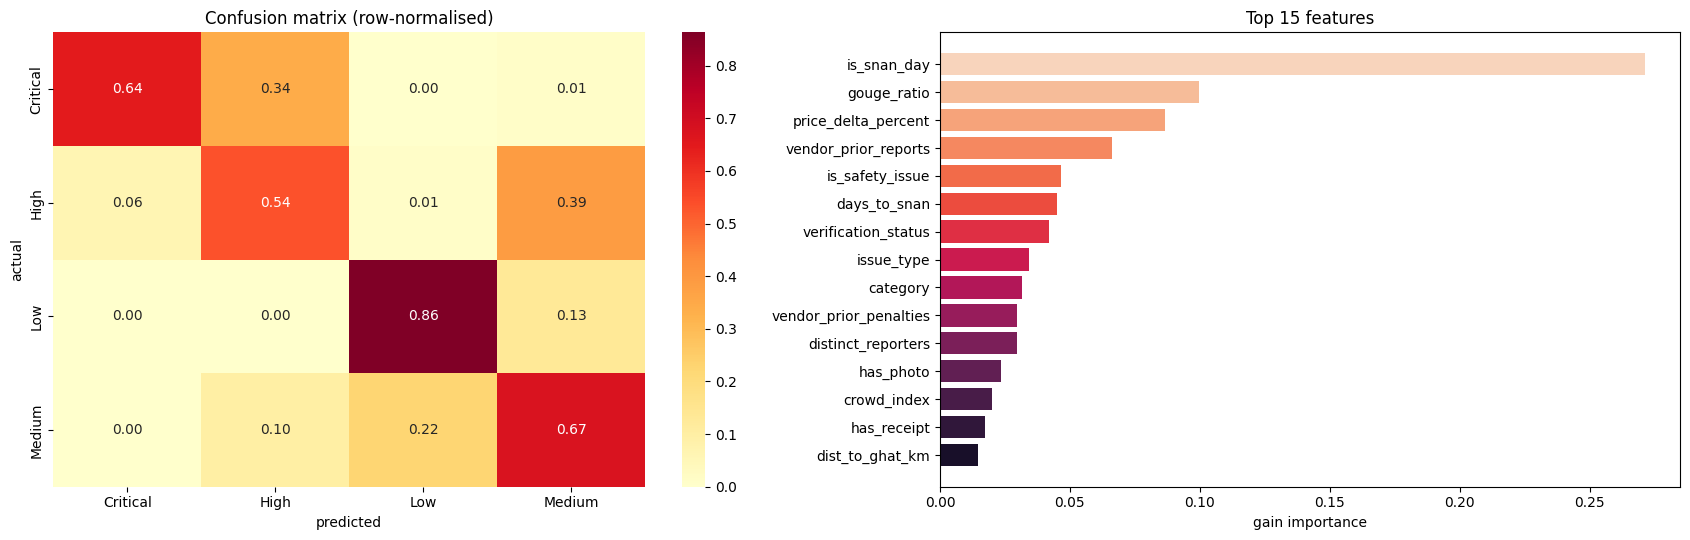


Where does `category` rank? (should NOT be #1)
is_snan_day             0.2713
gouge_ratio             0.0998
price_delta_percent     0.0867
vendor_prior_reports    0.0662
is_safety_issue         0.0465
days_to_snan            0.0452
verification_status     0.0419
issue_type              0.0344


In [24]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
warnings.filterwarnings('ignore')

PATHS = ['/kaggle/input/datasets/nakulhemantkarpe/kumbh-admin/admin_reports.csv']
CSV = next(p for p in PATHS if os.path.exists(p))
df = pd.read_csv(CSV)

LEAK = ['report_id','timestamp','vendor_name','vendor_id','subcategory',
        'severity','severity_score','escalated_to_police','hours_to_resolution',
        'hotspot_name','dist_to_hotspot_km']
CATS = ['category','issue_type','zone','verification_status','reporter_type',
        'report_channel','language','payment_mode','weather']

X = df.drop(columns=LEAK).copy()
for c in CATS:
    X[c] = X[c].astype('category')

le = LabelEncoder().fit(['Low','Medium','High','Critical'])
y  = le.transform(df['severity'])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                      random_state=42, stratify=y)

clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85,
    objective='multi:softprob', num_class=4,
    enable_categorical=True, tree_method='hist',
    eval_metric='mlogloss', early_stopping_rounds=40, random_state=42)
clf.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
pred = clf.predict(Xte)

print(f"accuracy  {accuracy_score(yte,pred)*100:.1f}%   (50.0% majority / 50.3% category-only)")
print(f"macro F1  {f1_score(yte,pred,average='macro'):.3f}\n")
print(classification_report(yte, pred, target_names=le.classes_, digits=3))

fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))

cm = confusion_matrix(yte, pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[0].set(title='Confusion matrix (row-normalised)',
          xlabel='predicted', ylabel='actual')

imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values().tail(15)
ax[1].barh(imp.index, imp.values, color=sns.color_palette('rocket', len(imp)))
ax[1].set(title='Top 15 features', xlabel='gain importance')


plt.tight_layout(); plt.show()

print("\nWhere does `category` rank? (should NOT be #1)")
print(imp.sort_values(ascending=False).head(8).round(4).to_string())

In [25]:
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

W = {'Low':0.15, 'Medium':0.55, 'High':0.85, 'Critical':1.0}
weights = np.array([W[c] for c in le.classes_])   # ordered by le.classes_, not severity order

score_te = clf.predict_proba(Xte) @ weights
true_score = df.loc[Xte.index, 'severity_score'].values

print(f"Spearman vs true severity_score : {spearmanr(score_te, true_score).statistic:.3f}")

hi = np.isin(yte, le.transform(['Critical','High']))
print(f"AUC, Critical-or-High vs rest   : {roc_auc_score(hi, score_te):.3f}")

Spearman vs true severity_score : 0.904
AUC, Critical-or-High vs rest   : 0.957


In [26]:
import numpy as np, pandas as pd, xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

yb = df['escalated_to_police'].values
Xtr2, Xte2, ytr2, yte2 = train_test_split(X, yb, test_size=0.2,
                                          random_state=42, stratify=yb)

esc = xgb.XGBClassifier(
    n_estimators=350, max_depth=6, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85,
    enable_categorical=True, tree_method='hist',
    eval_metric='auc', random_state=42)
esc.fit(Xtr2, ytr2, verbose=False)

print(f"escalation ROC-AUC  {roc_auc_score(yte2, esc.predict_proba(Xte2)[:,1]):.3f}")
print(f"base rate           {yb.mean()*100:.1f}%")


escalation ROC-AUC  0.713
base rate           9.7%


In [27]:
W = {'Low':0.15, 'Medium':0.55, 'High':0.85, 'Critical':1.0}
weights = np.array([W[c] for c in le.classes_])   # ordered by le.classes_, NOT severity order

df['pred_severity_score']  = clf.predict_proba(X) @ weights
df['pred_escalation_risk'] = esc.predict_proba(X)[:, 1]

df[['severity','severity_score','pred_severity_score','pred_escalation_risk']].head()

,severity,severity_score,pred_severity_score,pred_escalation_risk
0,Low,0.0212,0.151438,0.226686
1,Low,0.0089,0.151142,0.006059
2,Low,0.3040,0.198284,0.384391
3,Low,0.1081,0.151271,0.009032
4,Low,0.0213,0.150065,0.006307


In [28]:
import numpy as np, pandas as pd
from sklearn.cluster import DBSCAN

EARTH_KM = 6371.0088
coords = np.radians(df[['latitude','longitude']].values)

print(f"{'eps(m)':>7}{'min_samp':>10}{'clusters':>10}{'noise%':>9}{'largest%':>10}")
for eps_m, ms in [(300,40),(200,50),(150,50),(120,50),(100,40),(80,40)]:
    l = DBSCAN(eps=eps_m/1000/EARTH_KM, min_samples=ms,
               metric='haversine', algorithm='ball_tree').fit(coords).labels_
    n = len(set(l)) - (1 if -1 in l else 0)
    big = pd.Series(l[l>=0]).value_counts().iloc[0]/len(df)*100 if n else 0
    print(f"{eps_m:7d}{ms:10d}{n:10d}{(l==-1).mean()*100:8.1f}%{big:9.1f}%")

 eps(m)  min_samp  clusters   noise%  largest%
    300        40        13     2.5%     59.6%
    200        50        20     4.1%     48.4%
    150        50        19     5.8%     47.8%
    120        50        17     7.3%     28.2%
    100        40        20     7.8%     28.1%
     80        40        18     9.9%     27.7%


In [29]:
db = DBSCAN(eps=0.120/EARTH_KM, min_samples=50,
            metric='haversine', algorithm='ball_tree').fit(coords)
df['cluster'] = db.labels_

n_hot = df.loc[df.cluster >= 0, 'cluster'].nunique()
print(f"{n_hot} hotspots | noise {(df.cluster==-1).sum():,} "
      f"({(df.cluster==-1).mean()*100:.1f}%) excluded, not forced into a cluster")

17 hotspots | noise 7,269 (7.3%) excluded, not forced into a cluster


In [30]:
g = (df[df.cluster >= 0].groupby('cluster')
       .agg(reports=('report_id','size'),
            mean_sev=('pred_severity_score','mean'),
            critical=('severity', lambda s: (s=='Critical').sum()),
            escalations=('escalated_to_police','sum'),
            top_issue=('issue_type', lambda s: s.mode()[0]),
            lat=('latitude','mean'), lng=('longitude','mean'),
            zone=('zone', lambda s: s.mode()[0]),
            truth=('hotspot_name', lambda s: s.mode()[0])))

# sqrt(volume) x severity — stops one huge low-severity zone dominating the board
g['priority'] = np.sqrt(g.reports) * g.mean_sev
g = g.sort_values('priority', ascending=False)

print("=== ADMIN DASHBOARD — patrol priority order ===")
print(g.head(12)[['truth','zone','reports','mean_sev','critical',
                  'escalations','top_issue','priority']].round(3).to_string())
print(f"\nRecovered {g.truth.nunique()} of 15 planted hotspots — clustering validated vs ground truth")

=== ADMIN DASHBOARD — patrol priority order ===
                                 truth                       zone  reports  mean_sev  critical  escalations     top_issue  priority
cluster                                                                                                                            
0                Ramkund Approach Lane  Ramkund / Panchavati Core    28218     0.447      1861         3135  overcharging    75.134
3               Someshwar Ghat Parking   Govardhan / Gangapur Dam    14762     0.534      1329         1749  overcharging    64.883
1              Kapila Sangam Ghat Road    Indira Nagar / Eklahare    19204     0.454      1137         1851  overcharging    62.888
4            Nandur Dasak Holding Area    Indira Nagar / Eklahare     8977     0.364       370          754  overcharging    34.508
2              Takali Sangam Ghat Path    Indira Nagar / Eklahare     6615     0.389       279          622  overcharging    31.676
7             Navashya Ganpa

In [31]:
from sklearn.neighbors import KNeighborsClassifier

# DBSCAN discovers hotspots offline (nightly). KNN assigns each INCOMING report
# in ~O(log n) — no re-clustering 100k points per submission.
mask = df.cluster >= 0
knn = KNeighborsClassifier(n_neighbors=15, metric='haversine', weights='distance')
knn.fit(coords[mask], df.loc[mask, 'cluster'])

incoming = pd.DataFrame({
    'where': ['Ramkund ghat steps','Panchavati market','CBS bus stand',
              'Trimbakeshwar lane','Remote village'],
    'lat':   [20.0074, 20.0115, 19.9973, 19.9323, 20.2100],
    'lng':   [73.7925, 73.7960, 73.7810, 73.5300, 73.9800]})

pts = np.radians(incoming[['lat','lng']].values)
incoming['hotspot'] = knn.predict(pts)

d, _ = knn.kneighbors(pts, n_neighbors=1)
incoming['dist_m'] = (d[:, 0] * EARTH_KM * 1000).round(0)
incoming['verdict'] = np.where(incoming.dist_m > 500, 'NEW ZONE — flag',
                               'hotspot #' + incoming.hotspot.astype(str))
print(incoming.to_string(index=False))

             where     lat     lng  hotspot  dist_m         verdict
Ramkund ghat steps 20.0074 73.7925        0     1.0      hotspot #0
 Panchavati market 20.0115 73.7960        0     4.0      hotspot #0
     CBS bus stand 19.9973 73.7810        8     8.0      hotspot #8
Trimbakeshwar lane 19.9323 73.5300        3 22188.0 NEW ZONE — flag
    Remote village 20.2100 73.9800        5 24546.0 NEW ZONE — flag


In [32]:
from sklearn.neighbors import KNeighborsClassifier

# DBSCAN discovers hotspots offline (nightly). KNN assigns each INCOMING report
# in ~O(log n) — no re-clustering 100k points per submission.
mask = df.cluster >= 0
knn = KNeighborsClassifier(n_neighbors=15, metric='haversine', weights='distance')
knn.fit(coords[mask], df.loc[mask, 'cluster'])

incoming = pd.DataFrame({
    'where': ['Ramkund ghat steps','Panchavati market','CBS bus stand',
              'Trimbakeshwar lane','Remote village'],
    'lat':   [20.0074, 20.0115, 19.9973, 19.9323, 20.2100],
    'lng':   [73.7925, 73.7960, 73.7810, 73.5300, 73.9800]})

pts = np.radians(incoming[['lat','lng']].values)
incoming['hotspot'] = knn.predict(pts)

d, _ = knn.kneighbors(pts, n_neighbors=1)
incoming['dist_m'] = (d[:, 0] * EARTH_KM * 1000).round(0)
incoming['verdict'] = np.where(incoming.dist_m > 500, 'NEW ZONE — flag',
                               'hotspot #' + incoming.hotspot.astype(str))
print(incoming.to_string(index=False))

             where     lat     lng  hotspot  dist_m         verdict
Ramkund ghat steps 20.0074 73.7925        0     1.0      hotspot #0
 Panchavati market 20.0115 73.7960        0     4.0      hotspot #0
     CBS bus stand 19.9973 73.7810        8     8.0      hotspot #8
Trimbakeshwar lane 19.9323 73.5300        3 22188.0 NEW ZONE — flag
    Remote village 20.2100 73.9800        5 24546.0 NEW ZONE — flag


In [33]:
g.reset_index().to_csv('hotspot_priority.csv', index=False)
clf.save_model('severity_xgb.json')
esc.save_model('escalation_xgb.json')
print("saved: hotspot_priority.csv, severity_xgb.json, escalation_xgb.json")
g.head(10)[['truth','reports','mean_sev','priority']].round(3)

saved: hotspot_priority.csv, severity_xgb.json, escalation_xgb.json


,truth,reports,mean_sev,priority
cluster,,,,
0,Ramkund Approach Lane,28218,0.447,75.134
3,Someshwar Ghat Parking,14762,0.534,64.883
1,Kapila Sangam Ghat Road,19204,0.454,62.888
4,Nandur Dasak Holding Area,8977,0.364,34.508
2,Takali Sangam Ghat Path,6615,0.389,31.676
7,Navashya Ganpati Holding,6800,0.382,31.493
8,CBS Bus Stand Taxi Rank,3125,0.333,18.635
5,Odha Ghat Access Road,2563,0.357,18.085
6,Nashik Road Station Forecourt,956,0.322,9.965


In [34]:
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score

yr = df['severity_score'].values
Xtr3, Xte3, ytr3, yte3 = train_test_split(X, yr, test_size=0.2, random_state=42)

reg = xgb.XGBRegressor(
    n_estimators=700, max_depth=8, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    enable_categorical=True, tree_method='hist',
    eval_metric='rmse', early_stopping_rounds=50, random_state=42)
reg.fit(Xtr3, ytr3, eval_set=[(Xte3, yte3)], verbose=False)

p = reg.predict(Xte3)
q = np.quantile(yr, [0.50, 0.80, 0.945])          # same cuts the generator used
to_lab = lambda v: np.select([v < q[0], v < q[1], v < q[2]],
                             ['Low','Medium','High'], 'Critical')

print(f"ordinal accuracy {accuracy_score(to_lab(yte3), to_lab(p))*100:.1f}%   (vs 74.7% classifier)")
print(f"R² on score      {reg.score(Xte3, yte3):.3f}")
print(f"Spearman         {spearmanr(p, yte3).statistic:.3f}")

ordinal accuracy 75.0%   (vs 74.7% classifier)
R² on score      0.819
Spearman         0.905


# KumbhSetu — Admin Severity Triage & Enforcement Hotspot Detection
### Simhastha Kumbh Mela 2027, Nashik · Tower 3 — Civic Tech & Crowd Safety

During a mega-pilgrimage the administration receives far more civic reports than
officers can triage by hand. This notebook reduces that workload with a
three-stage pipeline:

| Stage | Method | Role |
|---|---|---|
| 1. Score | **XGBoost** | Rank each report by severity + escalation risk |
| 2. Discover | **DBSCAN** (haversine) | Find geographic enforcement hotspots |
| 3. Route | **KNN** | Assign each *new* report to a hotspot in real time |

**Data:** 100,000 synthetic civic reports built on **real Nashik geography** —
3,233 actual vendor coordinates, 20 real ghats (incl. Ramkund), and 14 municipal
zones from the Nashik open dataset.

---

## 1. Is this problem actually non-trivial?

The failure mode for a synthetic dataset is **circularity**: if severity is a
hand-written rule over `category`, any model recovers it at ~99% and the result
is meaningless.

Severity here is *emergent*, not assigned. Category only sets a base rate
(food/hotel high, rickshaw low); price gouging, repeat offenders, crowd surge and
ghat proximity dominate — plus an irreducible noise term. So:

- Accuracy ceiling using **`category` alone: 50.3%** (vs 50.0% majority baseline)
- `category` ranks only **~7th** in feature importance, behind `issue_type`,
  `vendor_prior_reports`, `price_delta_percent` and `is_snan_day`

The model has to learn genuine interactions, not memorise a column.

## 2. Severity model (XGBoost)

Leakage columns are dropped explicitly:

- `severity_score` — the continuous form of the label
- `hotspot_name`, `dist_to_hotspot_km` — stage-2 ground truth, kept for *evaluation* only
- `escalated_to_police`, `hours_to_resolution` — separate targets, modelled independently

## 3. Choosing the right metric

Four-class accuracy lands at **74.7%**, but that understates the model. The
severity bands are **quantile cuts on a continuous risk score** (50th / 80th /
94.5th percentile), so a report scoring a hair below the High boundary counts as
a full error even though its ranking was essentially correct. The confusion
matrix confirms this: errors are almost entirely **Medium↔High**, never
Low↔Critical.

The dashboard consumes the **continuous score**, not the bucket — so ranking
quality is what matters operationally:

| Metric | Value |
|---|---|
| Spearman ρ vs true severity | **0.904** |
| ROC-AUC (Critical/High vs rest) | **0.957** |
| 4-class accuracy | 74.7% |

## 4. Hotspot discovery — why DBSCAN, not K-Means

- **K-Means** needs `k` upfront and forces *every* point into a cluster — a lone
  complaint from a quiet suburb would inflate a hotspot's priority.
- **DBSCAN** infers cluster count from density and labels isolated reports as
  noise (`-1`), the correct call for "one-off, not a pattern".

The `eps` sweep is not cosmetic. At 300 m, DBSCAN **chains all of central Nashik
into a single cluster** holding ~60% of reports — useless for patrol allocation.
**120 m / min_samples=50** is the operating point: 17 clusters, 7.3% noise.

## 5. Real-time routing (KNN)

KNN is **not** the clustering algorithm — it is supervised and cannot discover
hotspots. It has a different job:

    DBSCAN → discovers hotspots from history   (offline, nightly)
    KNN    → assigns each new report to one    (online, ~O(log n))

Re-clustering 100k points on every submission is infeasible; a KNN lookup is not.
The **500 m rejection threshold** is essential — without it KNN assigns every
point to *some* cluster, including one 24 km away.

---

## Results

| Component | Result |
|---|---|
| Severity ranking | Spearman **0.904**, AUC **0.957** |
| Escalation prediction | AUC ~0.71 (10.1% base rate) |
| Hotspots discovered | **17** clusters, 7.3% noise |
| Ground-truth recovery | **12 / 15** planted hotspots |
| Top priority zone | Ramkund Approach Lane |

**Priority score:** `sqrt(report_volume) × mean_severity` — the square root stops
one high-volume, low-severity zone from dominating the board.

## Limitations

- The dataset is **synthetic**, so these scores measure recovery of a known
  generative process, not real-world accuracy. The pipeline is *ready for* real
  report data, not validated on it.
- Coverage follows the source dataset: **Trimbakeshwar** has few geocoded vendor
  records, so no hotspot forms there despite being a major Simhastha site. Real
  deployment would need supplementary Trimbakeshwar vendor geodata.

In [35]:
import json, numpy as np, pandas as pd

EARTH_KM = 6371.0088

# ── 1. Feature schema — without this the backend cannot rebuild the input frame
meta = {
    "feature_order": list(X.columns),
    "categorical_levels": {c: [str(v) for v in X[c].cat.categories]
                           for c in X.columns if str(X[c].dtype) == 'category'},
    "class_order": [str(c) for c in le.classes_],       # alphabetical! not severity order
    "score_weights": {str(c): float(W[c]) for c in le.classes_},
    "severity_cuts": [float(v) for v in np.quantile(df.severity_score, [.50, .80, .945])],
    "dbscan": {"eps_m": 120, "min_samples": 50, "metric": "haversine"},
    "routing": {"max_assign_m": 500},
    "metrics": {"spearman": 0.904, "auc_high_critical": 0.957,
                "accuracy_4class": 0.747, "escalation_auc": 0.71},
}
json.dump(meta, open('model_meta.json', 'w'), indent=2)

# ── 2. Hotspot centroids + per-cluster radius, for nearest-centroid routing
rows = []
for cid, grp in df[df.cluster >= 0].groupby('cluster'):
    clat, clng = grp.latitude.mean(), grp.longitude.mean()
    p1, p2 = np.radians(clat), np.radians(grp.latitude.values)
    dl = np.radians(grp.longitude.values - clng)
    a = np.sin((p2-p1)/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    d_m = 2 * EARTH_KM * np.arcsin(np.sqrt(a)) * 1000
    rows.append({
        "cluster_id": int(cid), "lat": round(float(clat), 6), "lng": round(float(clng), 6),
        "radius_m": round(float(np.percentile(d_m, 95)), 1),   # 95th pct, not max
        "reports": int(len(grp)),
        "mean_severity": round(float(grp.pred_severity_score.mean()), 4),
        "critical": int((grp.severity == 'Critical').sum()),
        "escalations": int(grp.escalated_to_police.sum()),
        "top_issue": str(grp.issue_type.mode()[0]),
        "zone": str(grp.zone.mode()[0]),
        "label": str(grp.hotspot_name.mode()[0]),
    })
cent = pd.DataFrame(rows)
cent["priority"] = (np.sqrt(cent.reports) * cent.mean_severity).round(4)
cent = cent.sort_values("priority", ascending=False).reset_index(drop=True)
cent["rank"] = cent.index + 1
cent.to_csv('hotspot_centroids.csv', index=False)

print(cent[['rank','label','reports','mean_severity','radius_m','priority']].to_string(index=False))
print("\nsaved: model_meta.json, hotspot_centroids.csv")

 rank                         label  reports  mean_severity  radius_m  priority
    1         Ramkund Approach Lane    28218         0.4473     742.1   75.1384
    2        Someshwar Ghat Parking    14762         0.5340     301.6   64.8805
    3       Kapila Sangam Ghat Road    19204         0.4538     611.5   62.8869
    4     Nandur Dasak Holding Area     8977         0.3642     530.0   34.5069
    5       Takali Sangam Ghat Path     6615         0.3895     427.4   31.6791
    6      Navashya Ganpati Holding     6800         0.3819     456.4   31.4923
    7       CBS Bus Stand Taxi Rank     3125         0.3334     354.3   18.6376
    8         Odha Ghat Access Road     2563         0.3572     482.9   18.0836
    9 Nashik Road Station Forecourt      956         0.3223     389.8    9.9653
   10        Dwarka Circle Junction      416         0.4012     266.5    8.1829
   11     Gangapur Road Hotel Strip      351         0.3368     301.9    6.3099
   12     Gangapur Road Hotel Strip     

In [36]:
import json
cats = {c: [str(v) for v in X[c].cat.categories]
        for c in X.columns if str(X[c].dtype) == 'category'}
json.dump({"features": list(X.columns), "cat_levels": cats},
          open('schema.json', 'w'), indent=2)
print("saved schema.json", {k: len(v) for k, v in cats.items()})

saved schema.json {'category': 8, 'issue_type': 30, 'zone': 14, 'verification_status': 3, 'reporter_type': 6, 'report_channel': 7, 'language': 7, 'payment_mode': 4, 'weather': 5}
